libaraies

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [2]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [3]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [4]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [5]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [6]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [7]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [8]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [9]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


get_sniff_respiratory_rate function is good for calculating the breathing rate during a sniff bout:

It creates a mask to select the respiratory signal samples between sniff_start and sniff_end.

It uses find_peaks to detect inhalation peaks in that signal segment, with a minimum peak distance of 0.2 seconds (to avoid counting the same breath twice).

It calculates the duration of the sniff bout.

It returns the breathing rate as the number of detected peaks divided by the duration (giving rate in Hz).

A few things to watch out for:
Sampling rate consistency: Make sure the times array and the signal array are aligned and that sampling_rate matches the sampling frequency of the signal.

Peak detection threshold: You might want to tweak the distance or add a height parameter in find_peaks if you get too many or too few peaks.

Edge cases: If duration is zero or very small, it returns np.nan, which is good.



In [10]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout or whole trial ie sniff_start = trial_start and sniff_end = trial_end.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # 0.0833 seconds corresponds to 12 Hz

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

In [11]:
ri_session_rates = []

for trial, entry in resp_data.items():
    signal = entry['signal']
    time = entry['time']
    sampling_rate = entry['sampling_rate']

    # Get full duration
    sniff_start = time[0]
    sniff_end = time[-1]

    # Compute respiration rate
    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=sampling_rate)

    # Get valence
    valence = 'RI1' if trial.startswith('RI1') else ('RI2' if trial.startswith('RI2') else 'Other')

    # Extract subject as 3.6 from RI1_3_6
    try:
        parts = trial.split('_')
        subject = f"{parts[1]}.{parts[2]}"
    except IndexError:
        subject = 'Unknown'

    ri_session_rates.append({
        'Trial': trial,
        'Valence': valence,
        'Subject': subject,
        'Respiration Rate (Hz)': rate
    })

# Convert to DataFrame
ri_session_df = pd.DataFrame(ri_session_rates)
print(ri_session_df.head())


     Trial Valence Subject  Respiration Rate (Hz)
0  RI1_3_6     RI1     3.6               7.270376
1  RI2_3_6     RI2     3.6               5.932787
2  RI1_4_7     RI1     4.7               7.564174
3  RI2_4_7     RI2     4.7               6.551133
4  RI1_2_3     RI1     2.3               7.285965


In [12]:
def extract_agent_anogenital_sniffs(df):
    """
    Filters BORIS dataframe for anogenital sniffing initiated by the social agent.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Filter for anogenital sniffing by the social agent
    agent_mask = df['Subject'].str.lower() == 'social_agent'
    sniff_mask = df['Behavior'].str.lower() == 'anogenital sniffing'

    return df[agent_mask & sniff_mask]


In [13]:
# Call the function on your BORIS dataframe
agent_anogenital_sniffs = extract_agent_anogenital_sniffs(RI2_4_7_boris)

# Optional: preview the result
print(agent_anogenital_sniffs.head())


        Observation id         Observation date  Description Observation type  \
10  RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   
12  RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   
17  RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   
18  RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   
20  RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   

                                                                                            Source  \
10  player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4   
12  player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4   
17  player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4   
18  player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4   
20 

ONE SUBJECT 3.6 WORKED

RUN LOOP ON ALL SUBJECTS WORKS

In [14]:
# List to collect all social agent-initiated anogenital sniffs
all_agent_sniffs = []

# Loop through RI1 trials
for label, boris_df in ri1_boris_data.items():
    agent_sniffs = extract_agent_anogenital_sniffs(boris_df)  # <-- updated function
    agent_sniffs["Trial"] = label
    agent_sniffs["Group"] = "RI1"
    all_agent_sniffs.append(agent_sniffs)

# Loop through RI2 trials
for label, boris_df in ri2_boris_data.items():
    agent_sniffs = extract_agent_anogenital_sniffs(boris_df)  # <-- updated function
    agent_sniffs["Trial"] = label
    agent_sniffs["Group"] = "RI2"
    all_agent_sniffs.append(agent_sniffs)

# Combine all into one DataFrame
combined_sniffs_df = pd.concat(all_agent_sniffs, ignore_index=True)


In [15]:
combined_sniffs_df

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop,Trial,Group,Media file,Total length,FPS,Modifiers
0,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,anogenital sniffing,Not defined,STATE,8.862,9.448,0.586,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,257.0,274.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
1,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,anogenital sniffing,Not defined,STATE,80.310,85.552,5.242,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,2329.0,2481.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
2,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,anogenital sniffing,Not defined,STATE,90.690,91.862,1.172,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,2630.0,2664.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
3,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,anogenital sniffing,Not defined,STATE,260.862,265.276,4.414,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,7565.0,7693.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
4,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,anogenital sniffing,Not defined,STATE,597.517,597.759,0.242,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,17329.0,17336.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
5,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,social_agent,3.399,anogenital sniffing,Not defined,STATE,346.067,346.300,0.233,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,10383.0,10390.0,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
6,RI1_s2_3_p5_3_nRB3_20250622_104059.1,2025-07-01 16:32:15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,social_agent,NaN,anogenital sniffing,NaN,STATE,85.222,92.717,7.495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RI1_2_3,RI1,/Users/ayushjain/Downloads/RI1_s2_3_p5_3_nRB3_20250622_104059.1.mov,602.00,30.0,NaN
7,RI1_s4_8_p5_1_nRB3,2025-07-02 21:32:00.524,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_8_p5_1_nRB3_20250621_165214.1.mp4,0.0,526.234,603.200,30.0,social_agent,26.430,anogenital sniffing,Not defined,STATE,18.700,19.000,0.300,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_8_p5_1_nRB3_20250621_165214.1.mp4,561.0,570.0,NaN,NaN,NaN,NaN,RI1_4_8,RI1,NaN,NaN,NaN,NaN
8,RI1_s4_8_p5_1_nRB3,2025-07-02 21:32:00.524,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_8_p5_1_nRB3_20250621_165214.1.mp4,0.0,526.234,603.200,30.0,social_agent,26.430,anogenital sniffing,Not defined,STATE,35.600,36.467,0.867,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_8_p5_1_nRB3_20250621_165214.1.mp4,1068.0,1094.0,NaN,NaN,NaN,NaN,RI1_4_8,RI1,NaN,NaN,NaN,NaN
9,RI1_s4_8_p5_1_nRB3,2025-07-02 21:32:00.524,NaN,Media file,player #1:C:/Use

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def calculate_percent_change_resp_rate(signal, time, sniff_start, sampling_rate=100, plot=True,
                                       baseline_color='gray', sniff_color='orange', post_color='skyblue',
                                       title=None):
    """
    Calculates % change in instantaneous respiration rate (Hz) around a sniff event.

    Windows:
    - Baseline: -5s to -1s
    - During:   0s to +0.5s
    - Post:     +0.5s to +1.5s

    Returns:
        pct_change_during, pct_change_post, baseline_rate, sniff_rate, post_rate
    """
    # Define time windows
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)
    post_mask = (time >= sniff_start + 0.5) & (time < sniff_start + 1.5)

    baseline_segment = signal[baseline_mask]
    sniff_segment = signal[sniff_mask]
    post_segment = signal[post_mask]

    min_distance_samples = int(0.0833 * sampling_rate)  # 75 ms minimum between breaths

    # Find peaks
    baseline_peaks, _ = find_peaks(baseline_segment, distance=min_distance_samples)
    sniff_peaks, _ = find_peaks(sniff_segment, distance=min_distance_samples)
    post_peaks, _ = find_peaks(post_segment, distance=min_distance_samples)

    # Convert to actual times
    baseline_peak_times = time[baseline_mask][baseline_peaks]
    sniff_peak_times = time[sniff_mask][sniff_peaks]
    post_peak_times = time[post_mask][post_peaks]

    # Inter-breath intervals
    baseline_ibis = np.diff(baseline_peak_times)
    sniff_ibis = np.diff(sniff_peak_times)
    post_ibis = np.diff(post_peak_times)

    if len(baseline_ibis) == 0 or len(sniff_ibis) == 0 or len(post_ibis) == 0:
        if plot:
            print("⚠️ Not enough peaks detected to calculate respiration rate change.")
        return None, None, None, None, None  # insufficient data

    # Instantaneous respiration rates
    baseline_rates = 1 / baseline_ibis
    sniff_rates = 1 / sniff_ibis
    post_rates = 1 / post_ibis

    # Mean rates
    baseline_mean_rate = np.mean(baseline_rates)
    sniff_mean_rate = np.mean(sniff_rates)
    post_mean_rate = np.mean(post_rates)

    # Percent changes
    pct_change_sniff = ((sniff_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100
    pct_change_post = ((post_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100

    # Plot
    if plot:
        plt.figure(figsize=(6, 5))
        plt.bar(
            ['Pre-sniff (−5 to −1s)', 'During sniff (0 to +0.5s)', 'Post-sniff (+0.5 to +1.5s)'],
            [baseline_mean_rate, sniff_mean_rate, post_mean_rate],
            color=[baseline_color, sniff_color, post_color]
        )
        plt.ylabel('Respiration Rate (Hz)')
        plt.title(title or f'Respiration Rate: Pre vs During vs Post\nΔDuring: {pct_change_sniff:.2f}%, ΔPost: {pct_change_post:.2f}%')
        plt.tight_layout()
        plt.show()

    return pct_change_sniff, pct_change_post, baseline_mean_rate, sniff_mean_rate, post_mean_rate



In [17]:
results = []

for i, sniff_row in combined_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]

    # Get respiration data for this trial
    resp_entry = resp_data.get(trial, None)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    # Run updated function
    pct_change_sniff, pct_change_post, baseline_rate, sniff_rate, post_rate = calculate_percent_change_resp_rate(
        signal, time, sniff_start, sampling_rate=sampling_rate, plot=False
    )

    # Skip if not enough peaks detected
    if pct_change_sniff is None:
        print(f"Not enough peaks detected for sniff at {sniff_start}s in trial {trial}, skipping...")
        continue

    # Store results
    results.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Percent Change During": pct_change_sniff,
        "Percent Change Post": pct_change_post,
        "Baseline Rate": baseline_rate,
        "During Sniff Rate": sniff_rate,
        "Post-sniff Rate": post_rate
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df.head())


     Trial  Sniff Start  Percent Change During  Percent Change Post  \
0  RI1_3_6        8.862               7.583608            40.394119   
1  RI1_3_6       80.310              12.690517            16.176803   
2  RI1_3_6       90.690             -19.595273             0.304359   
3  RI1_3_6      260.862              18.728792             0.665536   
4  RI1_3_6      597.517              19.126169             3.963663   

   Baseline Rate  During Sniff Rate  Post-sniff Rate  
0       6.084063           6.545455         8.541667  
1       8.979502          10.119048        10.432099  
2       9.396905           7.555556         9.425505  
3       8.656517          10.277778         8.714129  
4       8.012895           9.545455         8.330499  


C:\Users\sjs93\AppData\Local\Temp\ipykernel_1604\2853764855.py:46: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


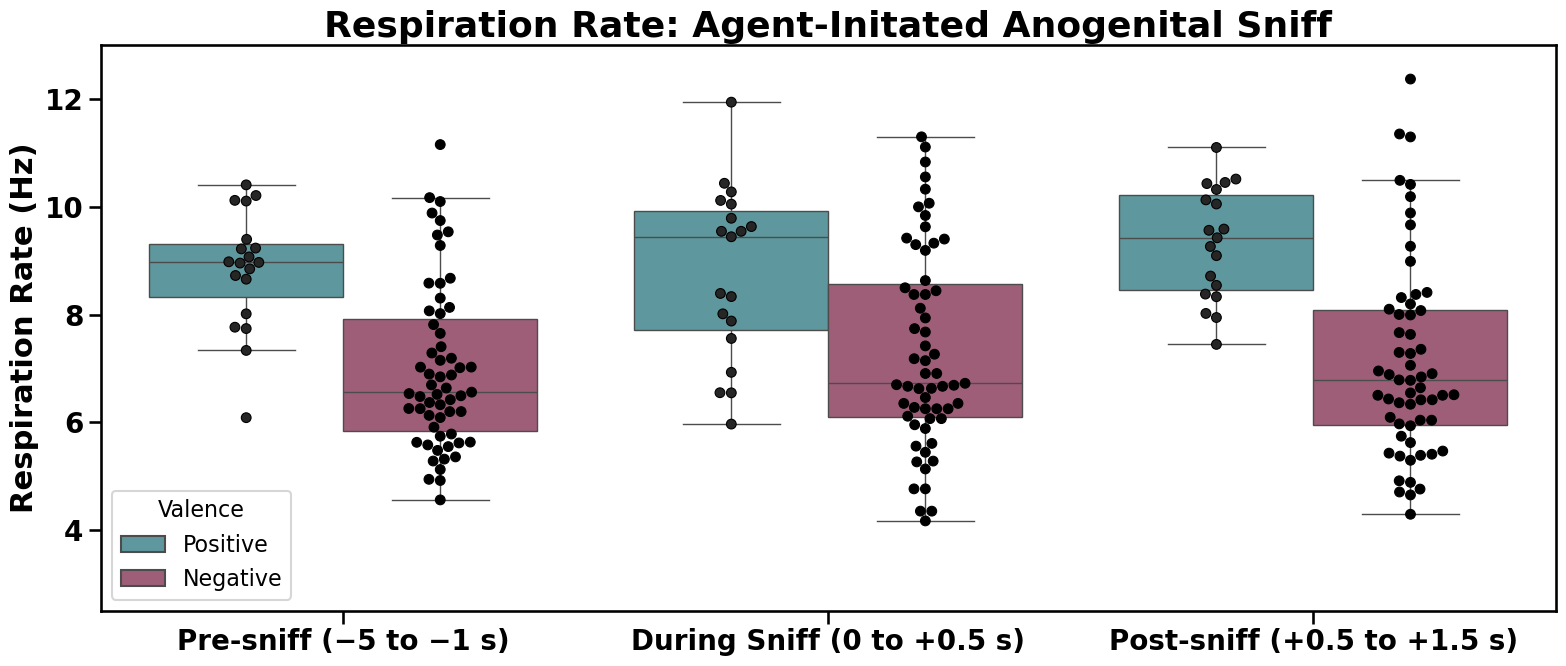

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom color palette
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

# Add Valence column
results_df['Valence'] = results_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
results_df = results_df[results_df['Valence'] != 'Unknown']

# Melt for long format plotting
plot_df = results_df.melt(
    id_vars=["Trial", "Sniff Start", "Valence"],
    value_vars=["Baseline Rate", "During Sniff Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Optional: Rename conditions for nicer x-axis labels
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (−5 to −1 s)",
    "During Sniff Rate": "During Sniff (0 to +0.5 s)",
    "Post-sniff Rate": "Post-sniff (+0.5 to +1.5 s)"
})

# Plot
plt.figure(figsize=(16, 7))
sns.set_context("talk")

# Boxplot
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot overlay
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=7,
    marker='o',
    linewidth=0.8,
    legend=False  # Avoid duplicate legends
)

# Legend and labels
plt.legend(title='Valence', loc='lower left', bbox_to_anchor=(0, 0))
plt.title("Respiration Rate: Agent-Initated Anogenital Sniff", fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=22, weight='bold')
plt.xlabel('')
plt.xticks(fontsize=20, weight='bold')
plt.yticks(ticks=[4, 6, 8, 10, 12],fontsize=20, weight='bold')
plt.ylim(2.5, 13)

plt.legend(title='Valence', fontsize=16, title_fontsize=16, loc='lower left', bbox_to_anchor=(0, 0))
plt.tight_layout()
plt.show()
